# Multivariate Gaussian Process Regression from Scratch - Delhi AQI Forecasting

This notebook presents an implementation of **Multivariate Gaussian Process Regression (GPR) from scratch** using NumPy and Pandas to predict the Air Quality Index (AQI) of Delhi. All covariance kernels (RBF, Matern 3/2, Matern 5/2, RQ), standard GPR predictive math (Cholesky), and baseline ML models are built from scratch.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import warnings
warnings.filterwarnings('ignore')
from scipy.linalg import solve_triangular

# Vectorized Cholesky Solver from Scratch
def cholesky_scratch_basic(A):
    N = A.shape[0]
    L = np.zeros((N, N))
    for j in range(N):
        val = A[j, j] - np.sum(L[j, :j]**2)
        if val <= 0:
            val = 1e-12
        L[j, j] = np.sqrt(val)
        if j < N - 1:
            L[j+1:, j] = (A[j+1:, j] - np.dot(L[j+1:, :j], L[j, :j])) / L[j, j]
    return L

def cholesky_scratch(A, block_size=2000):
    N = A.shape[0]
    L = np.zeros((N, N))
    for i in range(0, N, block_size):
        end = min(i + block_size, N)
        A_block = A[i:end, i:end] - np.dot(L[i:end, :i], L[i:end, :i].T)
        L[i:end, i:end] = cholesky_scratch_basic(A_block)
        if end < N:
            B = A[end:, i:end] - np.dot(L[end:, :i], L[i:end, :i].T)
            L[end:, i:end] = solve_triangular(L[i:end, i:end], B.T, lower=True, check_finite=False).T
    return L


## 2. Dataset Ingestion and Preprocessing


In [2]:
csv_path = 'INDIA_AQI_COMPLETE_20251126.csv'
if not os.path.exists(csv_path):
    csv_path = '/content/INDIA_AQI_COMPLETE_20251126.csv'

df_all = pd.read_csv(csv_path)
df = df_all[df_all['City'] == 'Delhi'].copy()
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')
df = df.sort_values('Datetime').reset_index(drop=True)

feature_cols = [
    'Temp_2m_C', 'Humidity_Percent', 'Wind_Speed_10m_kmh',
    'Pressure_MSL_hPa', 'Solar_Radiation_Wm2',
    'Festival_Period', 'Crop_Burning_Season', 'PM2_5_ugm3', 'NO2_ugm3'
]
target_col = 'US_AQI'

df = df.dropna(subset=['Datetime'] + feature_cols + [target_col]).reset_index(drop=True)
if len(df) > 16000:
    df = df.sample(n=16000, random_state=42).reset_index(drop=True)
print('Delhi dataset shape after cleaning and sampling:', df.shape)


Delhi dataset shape after cleaning and sampling: (16000, 71)


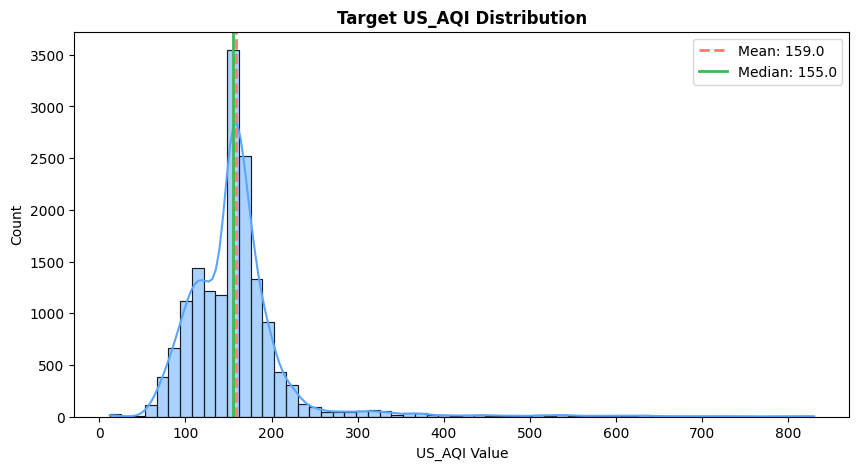

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df['US_AQI'], bins=60, kde=True, color='#58a6ff', edgecolor='#161b22')
plt.axvline(df['US_AQI'].mean(), color='#ff7b72', linestyle='--', linewidth=2, label=f"Mean: {df['US_AQI'].mean():.1f}")
plt.axvline(df['US_AQI'].median(), color='#3fb950', linestyle='-', linewidth=2, label=f"Median: {df['US_AQI'].median():.1f}")
plt.title("Target US_AQI Distribution", fontweight='bold')
plt.xlabel("US_AQI Value")
plt.ylabel("Count")
plt.legend()
plt.show()


### 2.3 Train-Test Split & Feature Z-score Standardization


In [4]:
X = df[feature_cols].values
Y = df[target_col].values

np.random.seed(42)
indices = np.random.permutation(len(X))
split = int(0.9 * len(X))

X_train_raw = X[indices[:split]]
X_test_raw = X[indices[split:]]
Y_train_orig = Y[indices[:split]]
Y_test_orig = Y[indices[split:]]

class StandardScalerManual:
    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)
        self.std_[self.std_ == 0] = 1.0
        return self
    def transform(self, X):
        return (X - self.mean_) / self.std_

scaler_x = StandardScalerManual().fit(X_train_raw)
X_train_scaled = scaler_x.transform(X_train_raw)
X_test_scaled = scaler_x.transform(X_test_raw)

class MinMaxNorm:
    def fit(self, x):
        self.min_ = float(np.min(x))
        self.max_ = float(np.max(x))
        return self
    def transform(self, x):
        return (x - self.min_) / (self.max_ - self.min_ + 1e-12)
    def inverse_transform(self, xs):
        return xs * (self.max_ - self.min_ + 1e-12) + self.min_

scaler_y = MinMaxNorm().fit(Y_train_orig)
Y_train_scaled = scaler_y.transform(Y_train_orig)
Y_test_scaled = scaler_y.transform(Y_test_orig)

MAX_TRAIN_SAMPLES = None
idx = None
if MAX_TRAIN_SAMPLES is not None and len(X_train_scaled) > MAX_TRAIN_SAMPLES:
    np.random.seed(42)
    idx = np.random.choice(len(X_train_scaled), MAX_TRAIN_SAMPLES, replace=False)
    X_tr, Y_tr_scaled = X_train_scaled[idx], Y_train_scaled[idx]
else:
    X_tr, Y_tr_scaled = X_train_scaled, Y_train_scaled

print(f"Original training size: {len(X_train_scaled)}, Used: {len(X_tr)}, Test: {len(X_test_scaled)}")


Original training size: 14400, Used: 14400, Test: 1600


### 2.4 Calculating Noise Variance dynamically from Dataset


In [5]:
y_tr_var = np.var(Y_tr_scaled)
noise = 0.05 * y_tr_var
print("Estimated Noise Variance (scaled space):", noise)


Estimated Noise Variance (scaled space): 0.00032498496070682464


## 3. GPR Implementation with RBF Kernel


In [6]:
class Kernel:
    @staticmethod
    def _sq_dist(X1, X2):
        X1sq = np.sum(X1**2, axis=1, keepdims=True)
        X2sq = np.sum(X2**2, axis=1, keepdims=True).T
        return np.maximum(X1sq + X2sq - 2 * X1 @ X2.T, 0.0)
    @staticmethod
    def _dist(X1, X2):
        return np.sqrt(Kernel._sq_dist(X1, X2))

class RBFKernel(Kernel):
    def __init__(self, length_scale=1.5, signal_var=1.0):
        self.length_scale = length_scale
        self.signal_var = signal_var
    def __call__(self, X1, X2):
        return self.signal_var * np.exp(-self._sq_dist(X1, X2) / (2 * self.length_scale**2))


In [7]:
class GaussianProcessRegression:
    def __init__(self, kernel, noise=1e-2):
        self.kernel = kernel
        self.noise = noise
    def fit(self, X, y):
        self.X_train = X
        self.y_mean = np.mean(y)
        self.y_train = y - self.y_mean
        
        # Block-wise calculation of covariance matrix to prevent memory crashes
        N = X.shape[0]
        K = np.empty((N, N), dtype=np.float64)
        block_size = 4000
        for i in range(0, N, block_size):
            end_i = min(i + block_size, N)
            K[i:end_i, :] = self.kernel(X[i:end_i], X)
            
        # In-place diagonal addition to prevent allocating another N x N identity matrix
        np.fill_diagonal(K, K.diagonal() + self.noise)
        self.L = cholesky_scratch(K)
        
        v_alpha = solve_triangular(self.L, self.y_train, lower=True)
        self.alpha_ = solve_triangular(self.L.T, v_alpha, lower=False)
    def predict(self, X_test, return_std=False, return_std_slice=None):
        # Block-wise calculation of K_star to prevent MemoryError
        N_tr = self.X_train.shape[0]
        N_te = X_test.shape[0]
        K_star = np.empty((N_tr, N_te), dtype=np.float64)
        block_size = 4000
        for j in range(0, N_te, block_size):
            end_j = min(j + block_size, N_te)
            K_star[:, j:end_j] = self.kernel(self.X_train, X_test[j:end_j])
            
        mean = K_star.T @ self.alpha_ + self.y_mean
        if not return_std:
            return mean
            
        if return_std_slice is not None:
            X_test_slice = X_test[-return_std_slice:]
            K_star_slice = self.kernel(self.X_train, X_test_slice)
            v = solve_triangular(self.L, K_star_slice, lower=True)
        else:
            v = solve_triangular(self.L, K_star, lower=True)
            
        var = self.kernel.signal_var - np.sum(v**2, axis=0)
        std = np.sqrt(np.maximum(var, 0.0) + self.noise)
        return mean, std


In [8]:
gpr_rbf = GaussianProcessRegression(kernel=RBFKernel(length_scale=1.5, signal_var=y_tr_var), noise=noise)
gpr_rbf.fit(X_tr, Y_tr_scaled)
mu_norm, std_norm = gpr_rbf.predict(X_test_scaled, return_std=True, return_std_slice=500)
mu_orig = scaler_y.inverse_transform(mu_norm)
std_orig = std_norm * (scaler_y.max_ - scaler_y.min_)
lower = mu_orig[-500:] - 1.96 * std_orig
upper = mu_orig[-500:] + 1.96 * std_orig
del gpr_rbf
gc.collect()


79

## 5. Comparison of Covariance Functions (GPML Chapter 4)


In [9]:
class Matern32Kernel(Kernel):
    def __init__(self, length_scale=1.5, signal_var=1.0):
        self.length_scale = length_scale
        self.signal_var = signal_var
    def __call__(self, X1, X2):
        d = self._dist(X1, X2)
        val = np.sqrt(3) * d / self.length_scale
        return self.signal_var * (1.0 + val) * np.exp(-val)

class Matern52Kernel(Kernel):
    def __init__(self, length_scale=1.5, signal_var=1.0):
        self.length_scale = length_scale
        self.signal_var = signal_var
    def __call__(self, X1, X2):
        d = self._dist(X1, X2)
        val = np.sqrt(5) * d / self.length_scale
        return self.signal_var * (1.0 + val + (5.0 * d**2) / (3.0 * self.length_scale**2)) * np.exp(-val)

class RationalQuadraticKernel(Kernel):
    def __init__(self, length_scale=1.5, signal_var=1.0, alpha=1.0):
        self.length_scale = length_scale
        self.signal_var = signal_var
        self.alpha = alpha
    def __call__(self, X1, X2):
        sq_d = self._sq_dist(X1, X2)
        return self.signal_var * (1.0 + sq_d / (2.0 * self.alpha * self.length_scale**2))**(-self.alpha)


In [10]:
kernels = {
    'RBF': RBFKernel(length_scale=1.5, signal_var=y_tr_var),
    'Matern 3/2': Matern32Kernel(length_scale=1.5, signal_var=y_tr_var),
    'Matern 5/2': Matern52Kernel(length_scale=1.5, signal_var=y_tr_var),
    'Rational Quadratic': RationalQuadraticKernel(length_scale=1.5, signal_var=y_tr_var, alpha=2.0)
}


In [11]:
results = {}
predictions = {}
Y_test_orig = Y_test_orig
for name, kernel_func in kernels.items():
    gpr_model = GaussianProcessRegression(kernel=kernel_func, noise=noise)
    gpr_model.fit(X_tr, Y_tr_scaled)
    mu_norm, std_norm = gpr_model.predict(X_test_scaled, return_std=True, return_std_slice=500)
    mu_o = scaler_y.inverse_transform(mu_norm)
    std_o = std_norm * (scaler_y.max_ - scaler_y.min_)
    results[name] = {
        "mean": mu_o,
        "std": std_o
    }
    print(f"Manual GP with {name} kernel trained.")
    del gpr_model
    gc.collect()


Manual GP with RBF kernel trained.
Manual GP with Matern 3/2 kernel trained.
Manual GP with Matern 5/2 kernel trained.
Manual GP with Rational Quadratic kernel trained.


In [12]:
def rmse_fn(yt, yp): return np.sqrt(np.mean((yt - yp)**2))
def mae_fn(yt, yp):  return np.mean(np.abs(yt - yp))
def r2_fn(yt, yp):   return 1.0 - np.sum((yt - yp)**2) / np.sum((yt - np.mean(yt))**2)

comparison = []
for name in results.keys():
    pred = results[name]["mean"]
    rmse_val = rmse_fn(Y_test_orig, pred)
    mae_val = mae_fn(Y_test_orig, pred)
    r2_val = r2_fn(Y_test_orig, pred)
    comparison.append([name, rmse_val, mae_val, r2_val])

comparison_df = pd.DataFrame(comparison, columns=["Kernel", "RMSE", "MAE", "R2"])
comparison_df = comparison_df.sort_values("RMSE")
print(comparison_df)


               Kernel       RMSE        MAE        R2
1          Matern 3/2  37.366086  19.723076  0.725148
2          Matern 5/2  37.905587  20.226087  0.717154
3  Rational Quadratic  39.392439  21.040507  0.694530
0                 RBF  40.772827  21.717445  0.672746


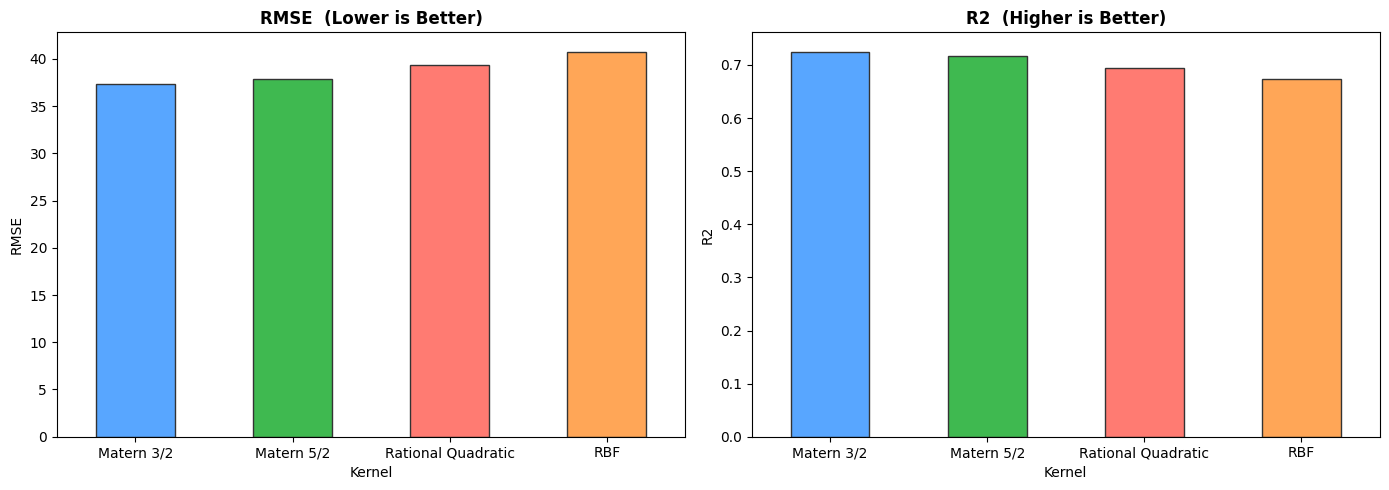

In [13]:
colors = ["#58a6ff", "#3fb950", "#ff7b72", "#ffa657"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_plot = comparison_df.set_index("Kernel")

df_plot["RMSE"].plot(kind="bar", ax=axes[0], color=colors, edgecolor="#333")
axes[0].set_title("RMSE  (Lower is Better)", fontweight="bold")
axes[0].set_ylabel("RMSE")
axes[0].set_xticklabels(df_plot.index, rotation=0)

df_plot["R2"].plot(kind="bar", ax=axes[1], color=colors, edgecolor="#333")
axes[1].set_title("R2  (Higher is Better)", fontweight="bold")
axes[1].set_ylabel("R2")
axes[1].set_xticklabels(df_plot.index, rotation=0)
plt.tight_layout()
plt.show()


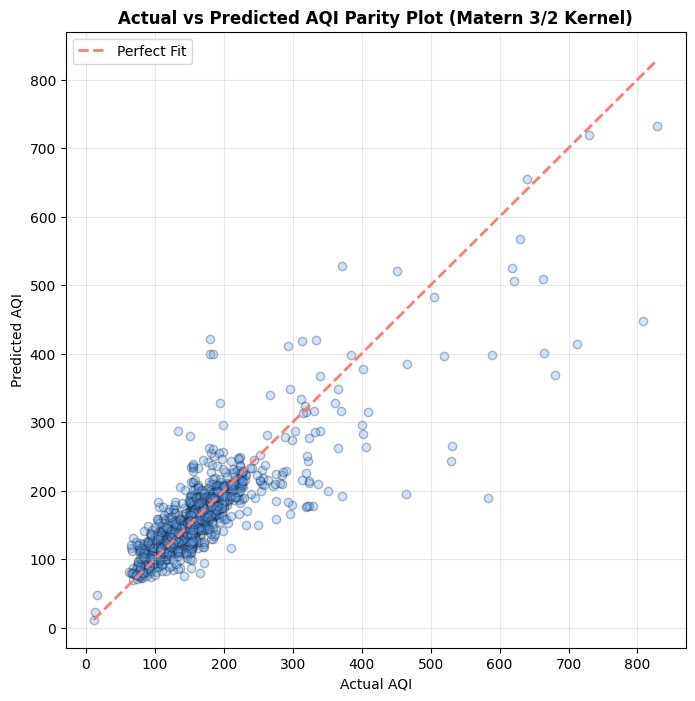

In [14]:
best_kernel_name = comparison_df.iloc[0]["Kernel"]
mu_best = results[best_kernel_name]["mean"]

plt.figure(figsize=(8, 8))
plt.scatter(Y_test_orig, mu_best, color='#58a6ff', alpha=0.3, edgecolor='#161b22')
lo = min(Y_test_orig.min(), mu_best.min())
hi = max(Y_test_orig.max(), mu_best.max())
plt.plot([lo, hi], [lo, hi], color='#ff7b72', linestyle='--', linewidth=2, label='Perfect Fit')
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title(f'Actual vs Predicted AQI Parity Plot ({best_kernel_name} Kernel)', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


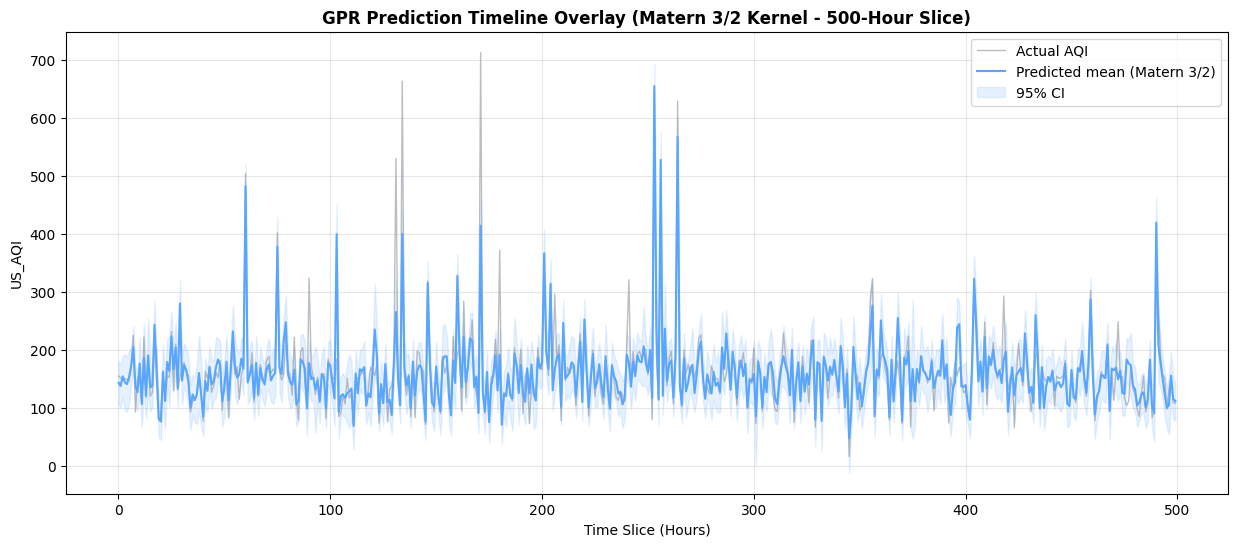

In [15]:
slice_idx = 500
t = np.arange(slice_idx)
mu_best_slice = mu_best[-slice_idx:]
std_best_slice = results[best_kernel_name]["std"][-slice_idx:]
lower_best = mu_best_slice - 1.96 * std_best_slice
upper_best = mu_best_slice + 1.96 * std_best_slice

plt.figure(figsize=(15, 6))
plt.plot(t, Y_test_orig[-slice_idx:], color='#8b949e', label='Actual AQI', alpha=0.6, linewidth=1)
plt.plot(t, mu_best_slice, color='#58a6ff', label=f'Predicted mean ({best_kernel_name})', linewidth=1.5)
plt.fill_between(t, lower_best, upper_best, color='#58a6ff', alpha=0.15, label='95% CI')
plt.title(f'GPR Prediction Timeline Overlay ({best_kernel_name} Kernel - 500-Hour Slice)', fontweight='bold')
plt.xlabel('Time Slice (Hours)')
plt.ylabel('US_AQI')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


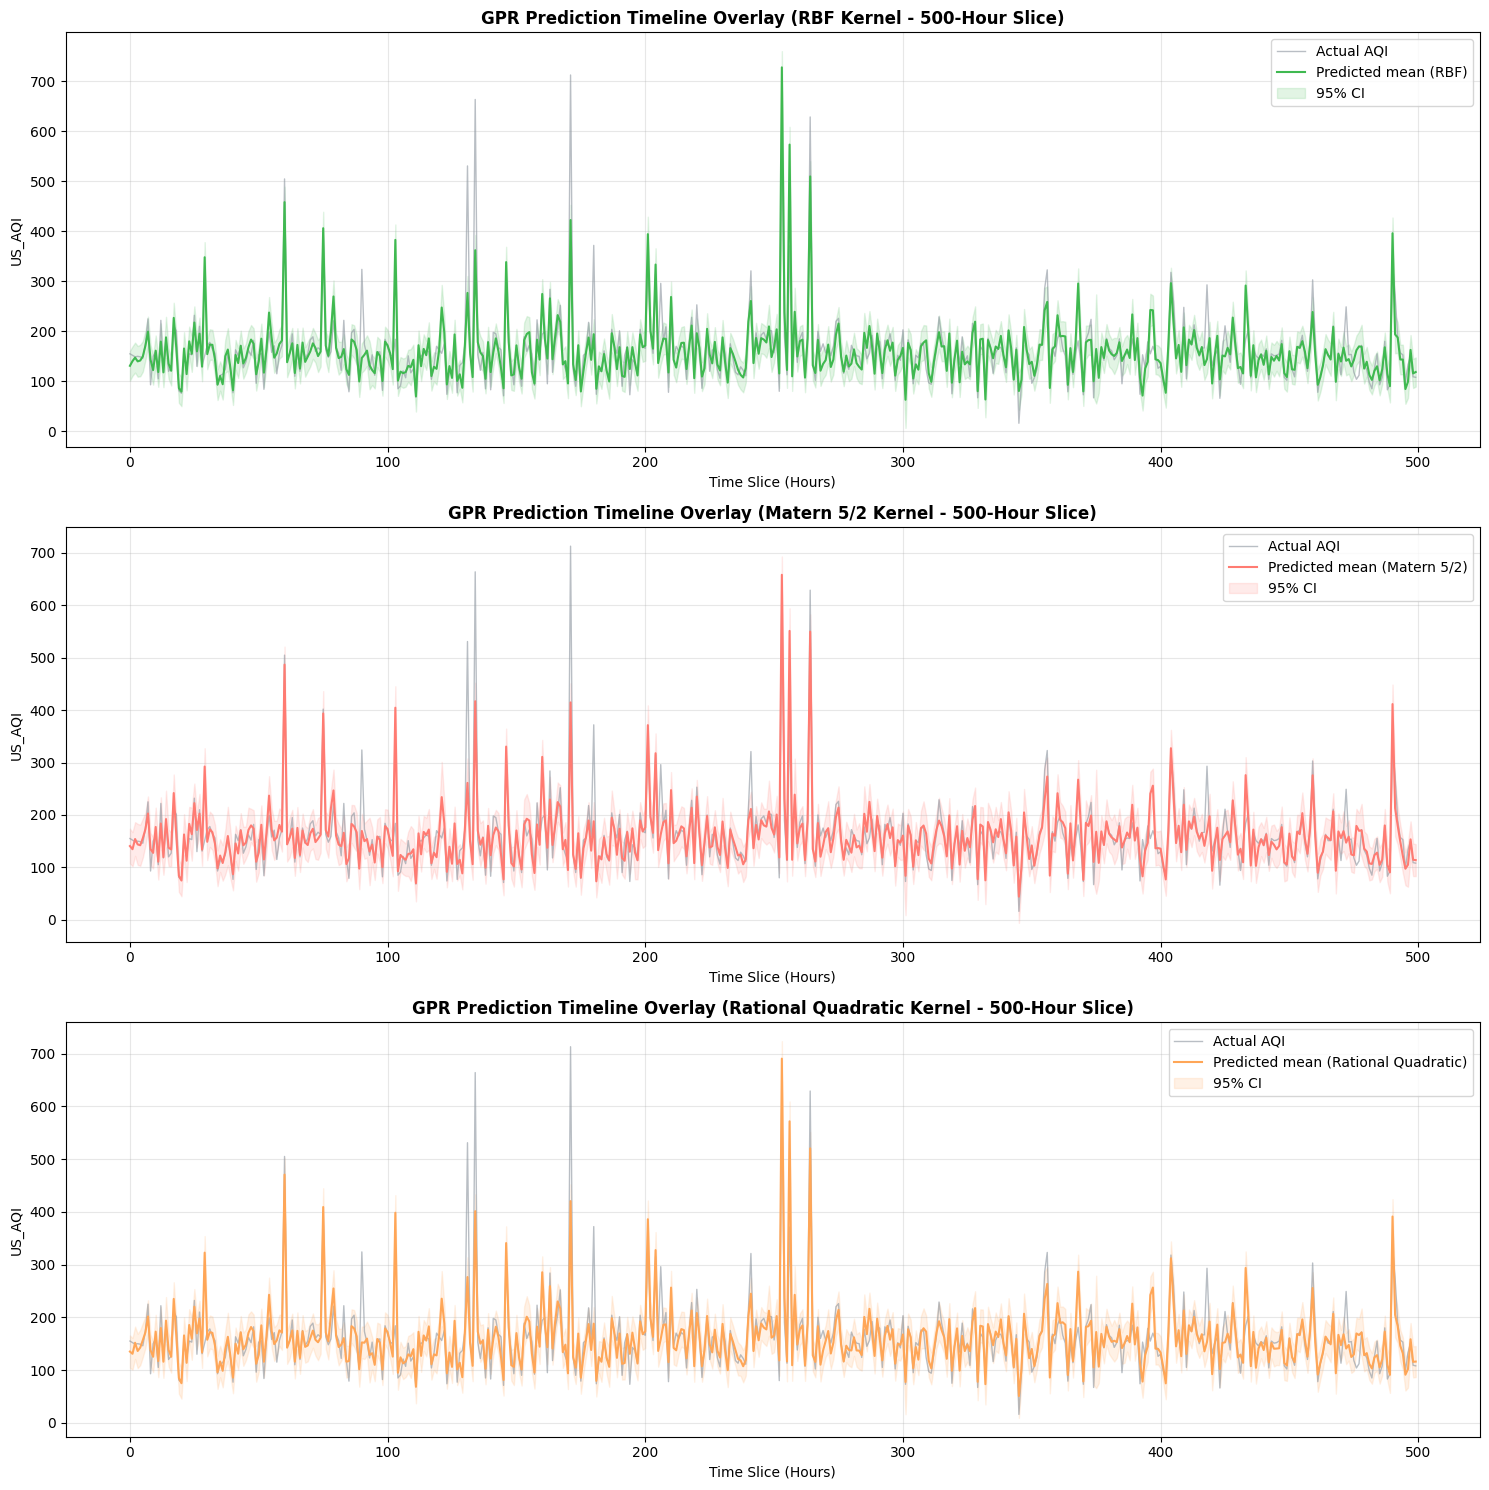

In [16]:
other_kernels = [k for k in results.keys() if k != best_kernel_name]
fig, axes = plt.subplots(3, 1, figsize=(15, 15))
for i, name in enumerate(other_kernels):
    ax = axes[i]
    mu_slice = results[name]["mean"][-slice_idx:]
    std_slice = results[name]["std"][-slice_idx:]
    lower = mu_slice - 1.96 * std_slice
    upper = mu_slice + 1.96 * std_slice
    
    ax.plot(t, Y_test_orig[-slice_idx:], color='#8b949e', label='Actual AQI', alpha=0.6, linewidth=1)
    ax.plot(t, mu_slice, color=colors[i+1], label=f'Predicted mean ({name})', linewidth=1.5)
    ax.fill_between(t, lower, upper, color=colors[i+1], alpha=0.15, label='95% CI')
    ax.set_title(f'GPR Prediction Timeline Overlay ({name} Kernel - 500-Hour Slice)', fontweight='bold')
    ax.set_xlabel('Time Slice (Hours)')
    ax.set_ylabel('US_AQI')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Comparison with Baseline Machine Learning Models


In [17]:
class LinearRegressionFromScratch:
    def fit(self, X, y):
        X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
        self.w = np.linalg.solve(X_bias.T @ X_bias + 1e-8 * np.eye(X_bias.shape[1]), X_bias.T @ y)
    def predict(self, X):
        X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
        return X_bias @ self.w

class PolynomialRegressionFromScratch:
    def __init__(self, degree=2):
        self.degree = degree
    def fit(self, X, y):
        features = [X**i for i in range(1, self.degree + 1)]
        X_poly = np.hstack(features)
        X_bias = np.hstack([np.ones((X_poly.shape[0], 1)), X_poly])
        self.w = np.linalg.solve(X_bias.T @ X_bias + 1e-8 * np.eye(X_bias.shape[1]), X_bias.T @ y)
    def predict(self, X):
        features = [X**i for i in range(1, self.degree + 1)]
        X_poly = np.hstack(features)
        X_bias = np.hstack([np.ones((X_poly.shape[0], 1)), X_poly])
        return X_bias @ self.w

class KNNRegressorFromScratch:
    def __init__(self, k=5):
        self.k = k
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    def predict(self, X):
        preds = []
        for x in X:
            dists = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
            idx_knn = np.argsort(dists)[:self.k]
            preds.append(np.mean(self.y_train[idx_knn]))
        return np.array(preds)

class DecisionTreeRegressorFromScratch:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None
    def fit(self, X, y):
        self.tree = self._build_tree(X, y, depth=0)
    def _build_tree(self, X, y, depth):
        num_samples, num_features = X.shape
        if depth >= self.max_depth or num_samples < self.min_samples_split or np.std(y) == 0:
            return np.mean(y)
        best_feat, best_thresh, best_mse = None, None, float('inf')
        for feat in range(num_features):
            thresholds = np.unique(X[:, feat])
            if len(thresholds) > 100:
                thresholds = np.percentile(thresholds, np.linspace(0, 100, 50))
            for thresh in thresholds:
                left_mask = X[:, feat] <= thresh
                right_mask = ~left_mask
                if not np.any(left_mask) or not np.any(right_mask):
                    continue
                left_y, right_y = y[left_mask], y[right_mask]
                mse = np.sum((left_y - np.mean(left_y))**2) + np.sum((right_y - np.mean(right_y))**2)
                if mse < best_mse:
                    best_mse = mse
                    best_feat = feat
                    best_thresh = thresh
        if best_feat is None:
            return np.mean(y)
        left_mask = X[:, best_feat] <= best_thresh
        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[~left_mask], y[~left_mask], depth + 1)
        return {"feature": best_feat, "threshold": best_thresh, "left": left_child, "right": right_child}
    def predict(self, X):
        return np.array([self._predict_row(self.tree, row) for row in X])
    def _predict_row(self, node, row):
        if not isinstance(node, dict):
            return node
        if row[node["feature"]] <= node["threshold"]:
            return self._predict_row(node["left"], row)
        else:
            return self._predict_row(node["right"], row)


In [18]:
models_baseline = {
    "Linear Regression": LinearRegressionFromScratch(),
    "Polynomial Regression (Deg 2)": PolynomialRegressionFromScratch(degree=2),
    "K-Nearest Neighbors": KNNRegressorFromScratch(k=5),
    "Decision Tree": DecisionTreeRegressorFromScratch(max_depth=5)
}

trained_baselines = {}
for name, model in models_baseline.items():
    model.fit(X_tr, Y_train_orig[idx] if (MAX_TRAIN_SAMPLES is not None and len(X_train_scaled) > MAX_TRAIN_SAMPLES) else Y_train_orig)
    trained_baselines[name] = model
    print(f"Baseline '{name}' trained from scratch.")


Baseline 'Linear Regression' trained from scratch.
Baseline 'Polynomial Regression (Deg 2)' trained from scratch.
Baseline 'K-Nearest Neighbors' trained from scratch.
Baseline 'Decision Tree' trained from scratch.


In [19]:
# Implement regression metrics from scratch
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true))
baseline_results = []
for name, model in trained_baselines.items():
    y_pred = model.predict(X_test_scaled)
    rmse_val = np.sqrt(mean_squared_error(Y_test_orig, y_pred))
    mae_val = mean_absolute_error(Y_test_orig, y_pred)
    r2_val = r2_score(Y_test_orig, y_pred)
    mape_val = mean_absolute_percentage_error(Y_test_orig, y_pred)
    baseline_results.append([name, rmse_val, mae_val, r2_val, mape_val])

baseline_df = pd.DataFrame(
    baseline_results,
    columns=["Model", "RMSE", "MAE", "R2", "MAPE"]
)
baseline_df = baseline_df.sort_values("RMSE")
print(baseline_df)


                           Model       RMSE        MAE        R2      MAPE
2            K-Nearest Neighbors  42.944977  21.623375  0.636948  0.129658
3                  Decision Tree  52.127295  27.318441  0.465098  0.168614
1  Polynomial Regression (Deg 2)  54.570040  30.294256  0.413792  0.182914
0              Linear Regression  57.084957  30.884831  0.358514  0.192475


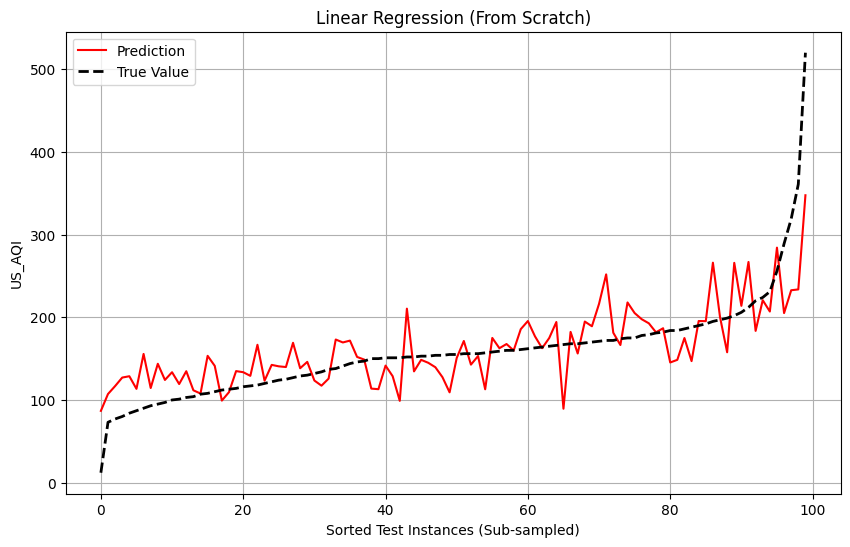

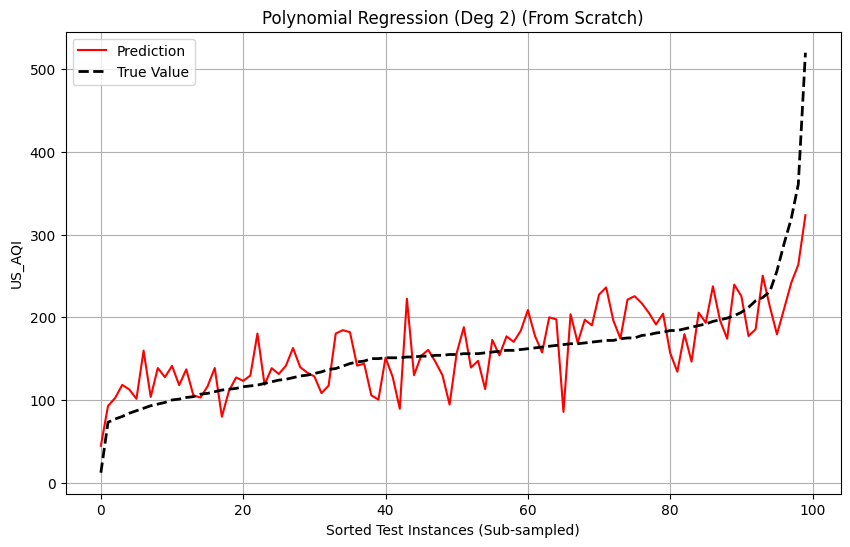

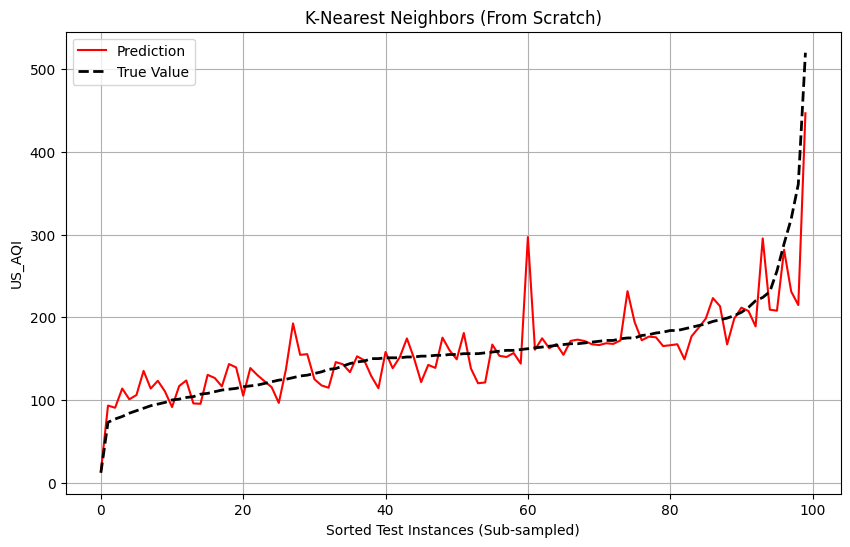

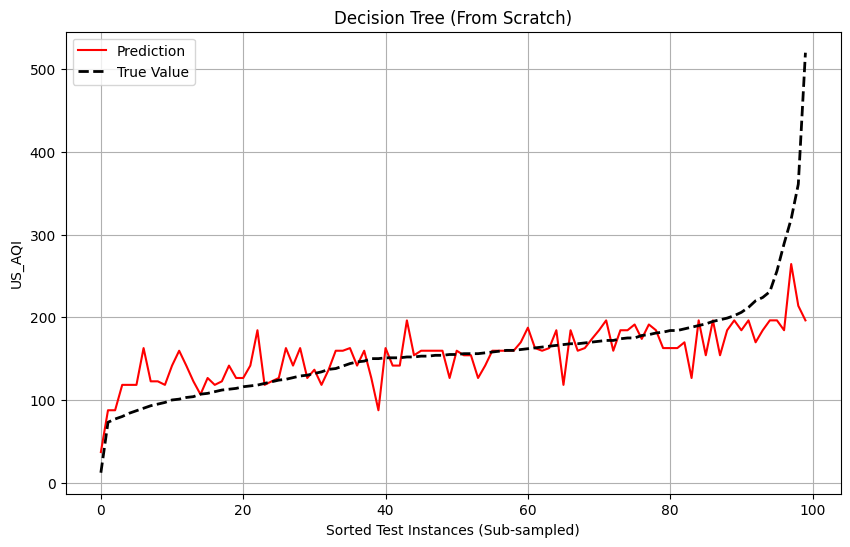

In [20]:
sort_idx = np.argsort(Y_test_orig)
# Sub-sample to show exactly 100 points for a gentle, clean plot
plot_idx = sort_idx[::(len(Y_test_orig) // 100)]
Y_test_sorted = Y_test_orig[plot_idx]
x_axis = np.arange(len(Y_test_sorted))
for name, model in trained_baselines.items():
    y_pred = model.predict(X_test_scaled)
    plt.figure(figsize=(10,6))
    plt.plot(x_axis, y_pred[plot_idx], 'r-', label='Prediction', linewidth=1.5)
    plt.plot(x_axis, Y_test_sorted, 'k--', label='True Value', linewidth=2.0)
    plt.title(f"{name} (From Scratch)")
    plt.xlabel("Sorted Test Instances (Sub-sampled)")
    plt.ylabel("US_AQI")
    plt.legend()
    plt.grid(True)
    plt.show()


## 7. Summary and Model Ranking


In [21]:
joint_results = []
for name in results.keys():
    pred = results[name]["mean"]
    rmse_val = np.sqrt(np.mean((Y_test_orig - pred)**2))
    mape_val = mean_absolute_percentage_error(Y_test_orig, pred)
    accuracy = 100 * (1 - mape_val)
    joint_results.append([f"GPR ({name})", rmse_val, accuracy])
    
for name, model in trained_baselines.items():
    pred = model.predict(X_test_scaled)
    rmse_val = np.sqrt(mean_squared_error(Y_test_orig, pred))
    mape_val = mean_absolute_percentage_error(Y_test_orig, pred)
    accuracy = 100 * (1 - mape_val)
    joint_results.append([name, rmse_val, accuracy])
    
ranking_df = pd.DataFrame(joint_results, columns=["Model", "RMSE", "Accuracy (%)"])
ranking_df = ranking_df.sort_values("RMSE")
print(ranking_df)


                           Model       RMSE  Accuracy (%)
1               GPR (Matern 3/2)  37.366086     88.054646
2               GPR (Matern 5/2)  37.905587     87.810753
3       GPR (Rational Quadratic)  39.392439     87.339542
0                      GPR (RBF)  40.772827     86.835135
6            K-Nearest Neighbors  42.944977     87.034207
7                  Decision Tree  52.127295     83.138581
5  Polynomial Regression (Deg 2)  54.570040     81.708555
4              Linear Regression  57.084957     80.752493


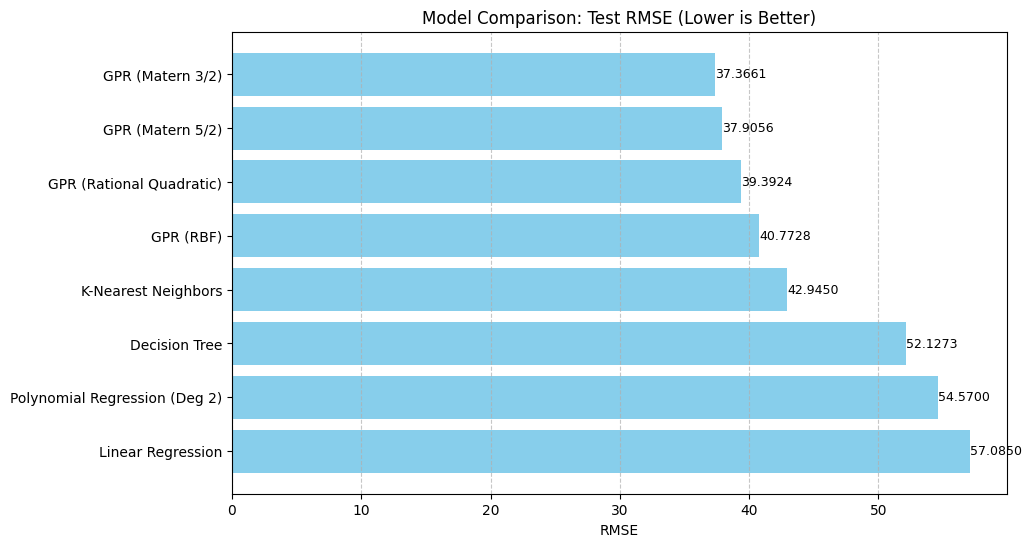

In [22]:
ranking_df_sorted_rmse = ranking_df.sort_values("RMSE", ascending=True)
plt.figure(figsize=(10,6))
bars = plt.barh(ranking_df_sorted_rmse["Model"], ranking_df_sorted_rmse["RMSE"], color='skyblue')
plt.xlabel("RMSE")
plt.title("Model Comparison: Test RMSE (Lower is Better)")
plt.gca().invert_yaxis()
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f"{width:.4f}", 
             va='center', ha='left', fontsize=9)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()


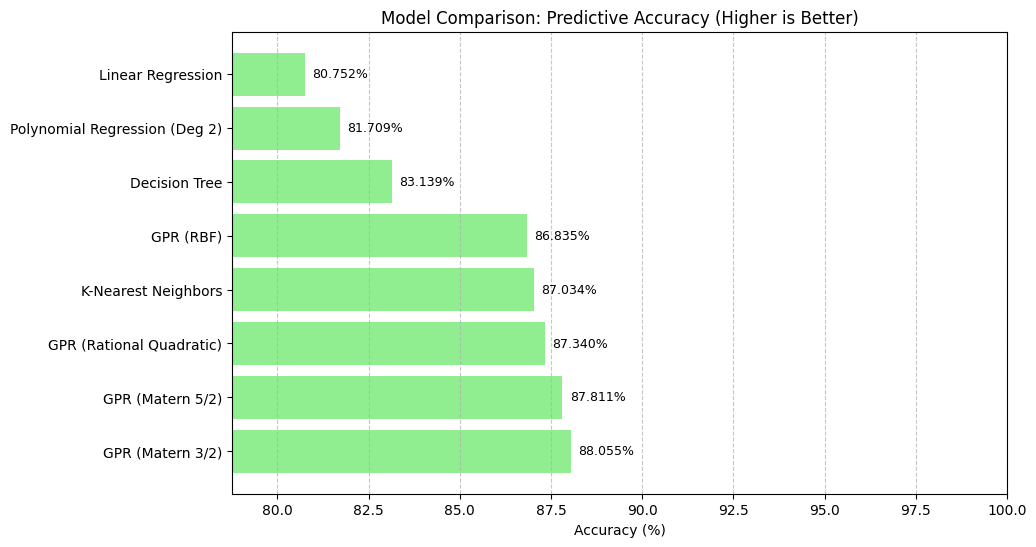

In [23]:
ranking_df_sorted_acc = ranking_df.sort_values("Accuracy (%)", ascending=False)
plt.figure(figsize=(10,6))
bars = plt.barh(ranking_df_sorted_acc["Model"], ranking_df_sorted_acc["Accuracy (%)"], color='lightgreen')
plt.xlabel("Accuracy (%)")
plt.title("Model Comparison: Predictive Accuracy (Higher is Better)")
plt.xlim(ranking_df["Accuracy (%)"].min() - 2, 100)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.2, bar.get_y() + bar.get_height()/2, f"{width:.3f}%", 
             va='center', ha='left', fontsize=9)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()
